In [122]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

import csv

In [116]:
INSTANCES = {
    "hamming6_2": "instances/stable_set/hamming6_2_stable_set_edge_list.txt",
    # "hamming6_4": "instances/stable_set/hamming6_4_stable_set_edge_list.txt",
    # "paley61":    "instances/stable_set/paley61_stable_set_edge_list.txt",
    "dsjc125.9":  "instances/stable_set/dsjc125.9_stable_set_edge_list.txt",
    # "keller4":    "instances/stable_set/keller4_stable_set_edge_list.txt",
    # "MANN_9":     "instances/stable_set/MANN_a9_stable_set_edge_list.txt",
    "C125.9":     "instances/stable_set/C125.9_stable_set_edge_list.txt",
    "evil_myc5x24": "instances/stable_set/evil-N120-p98-myc5x24_stable_set_edge_list.txt",
}

TRUE_VALUES = {
    "hamming6_2": 32,
    # "hamming6_4": 4,
    # "paley61": 5,
    "dsjc125.9": 34,
    # "keller4": 11,
    # "MANN_9": 16,
    "C125.9": 34,
    "evil_myc5x24": 48,
}
A = 1.0
B_RATIOS = [1.5, 2, 3, 5, 10, 20]
BASES = [3, 4, 5, 10, 15, 20]
NUM_ATTEMPTS = 50
MAX_ITERS = 3000
SEED = 0

In [117]:
param_sweep_path = "../results/param_sweep_results.csv"

with open(param_sweep_path, 'r') as f:
    reader = csv.DictReader(f)
    data = list(reader)
data[0]

{'instance': 'hamming6_2',
 'n': '64',
 'm': '192',
 'A': '1.0',
 'B': '1.5',
 'ratio': '1.5',
 'base': '3',
 'best': '23',
 'mean': '18.84',
 'std': '2.1758676430334636',
 'sizes': '[22, 18, 16, 17, 17, 18, 15, 19, 19, 23, 18, 16, 20, 19, 18, 20, 23, 23, 22, 21, 18, 18, 17, 18, 18, 21, 19, 15, 15, 23, 16, 19, 17, 18, 19, 17, 19, 17, 21, 18, 22, 18, 20, 22, 19, 17, 20, 21, 17, 19]'}

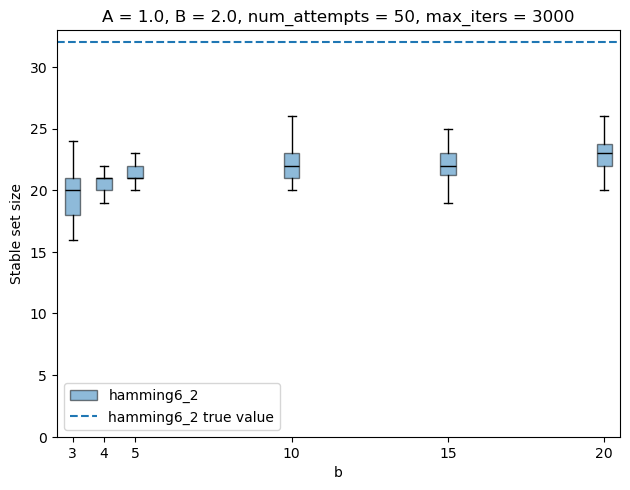

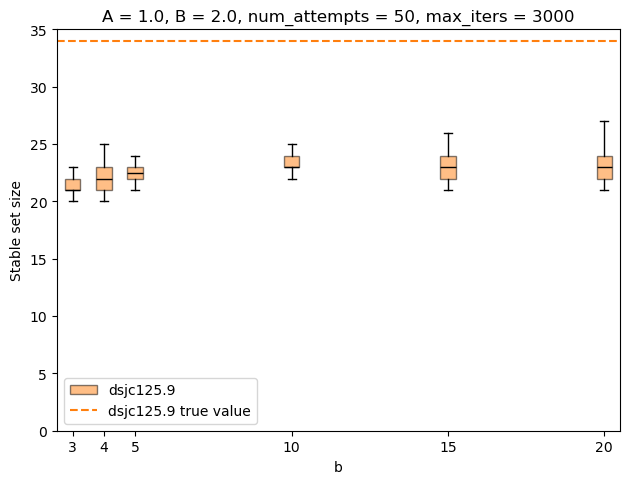

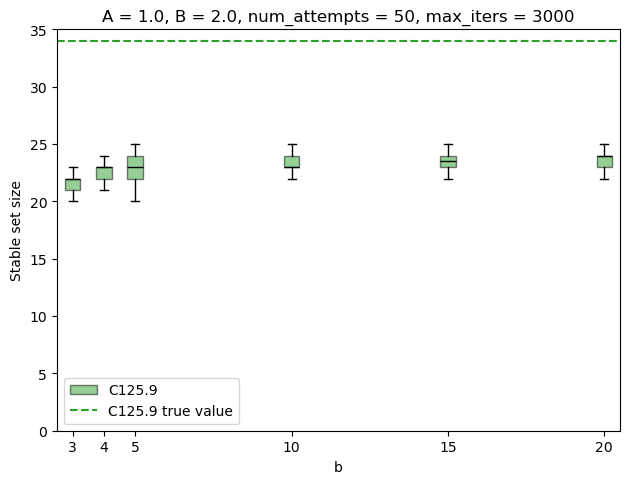

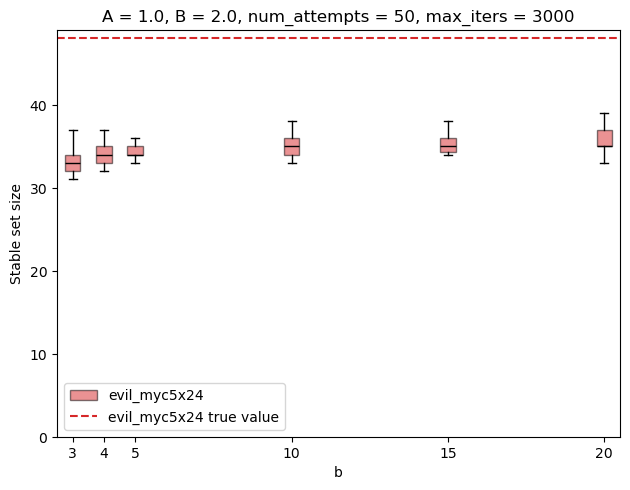

In [118]:

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

ratio = "2"

for i, (instance, size) in enumerate(INSTANCES.items()):
    data_per_instance = [e for e in data if e["instance"] == instance]
    data_per_base = [e for e in data_per_instance if e["ratio"] == ratio]
    bases = np.array([int(e["base"]) for e in data_per_base])
    sizes = np.array([e["sizes"] for e in data_per_base])
    sizes = [list(map(int, s.strip("[]").split(","))) for s in sizes]
    plt.boxplot(sizes, positions=bases, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    plt.axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")

    plt.ylim(0, TRUE_VALUES[instance] + 1)
    plt.legend()
    plt.xlabel("b")
    plt.ylabel("Stable set size")
    plt.tight_layout()
    plt.title(f"A = {A}, B = {float(ratio) * A}, num_attempts = {NUM_ATTEMPTS}, max_iters = {MAX_ITERS}")
    plt.show()

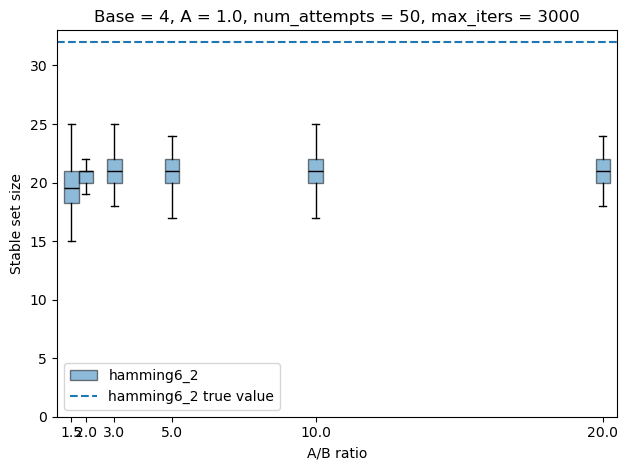

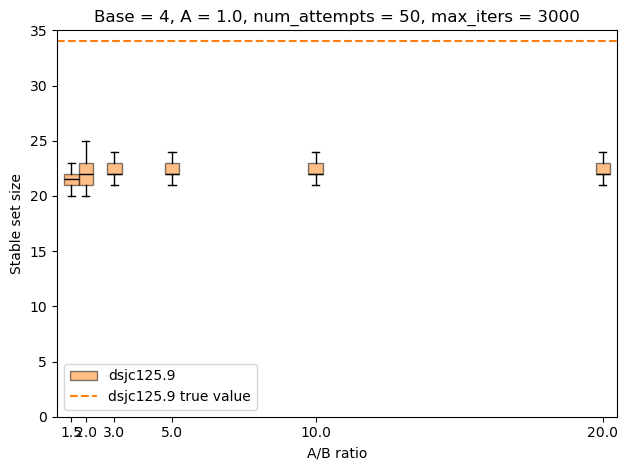

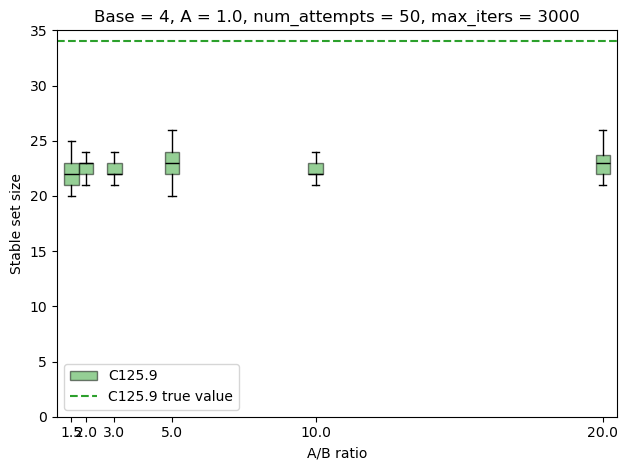

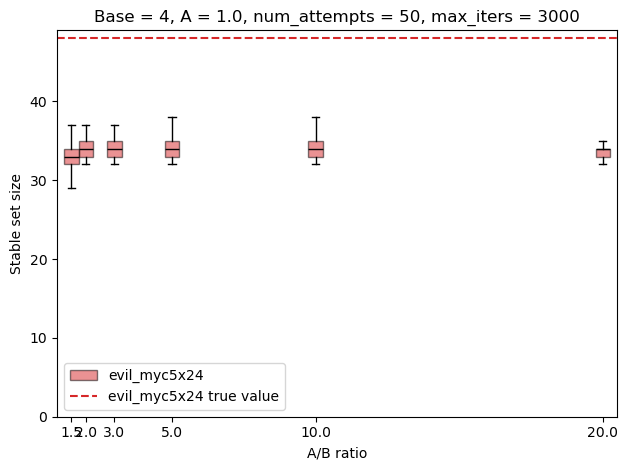

In [119]:

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

base = "4"

for i, (instance, size) in enumerate(INSTANCES.items()):
    data_per_instance = [e for e in data if e["instance"] == instance]
    data_per_base = [e for e in data_per_instance if e["base"] == base]
    ratios = np.array([float(e["ratio"]) for e in data_per_base])
    sizes = np.array([e["sizes"] for e in data_per_base])
    sizes = [list(map(int, s.strip("[]").split(","))) for s in sizes]
    plt.boxplot(sizes, positions=ratios, widths=0.5, patch_artist=True, boxprops=dict(facecolor=colors[i], alpha=0.5), medianprops=dict(color="black"), showfliers=False, label=f"{instance}")
    plt.axhline(y=TRUE_VALUES[instance], color=colors[i], linestyle="--", label=f"{instance} true value")

    plt.ylim(0, TRUE_VALUES[instance] + 1)
    plt.legend()
    plt.xlabel("A/B ratio")
    plt.ylabel("Stable set size")
    plt.title(f"Base = {base}, A = {A}, num_attempts = {NUM_ATTEMPTS}, max_iters = {MAX_ITERS}")
    plt.tight_layout()
    plt.show()

In [134]:
benchmark_stable_set_path = "../results/benchmark_stable_set_results.csv"
benchmark_results = pd.read_csv(benchmark_stable_set_path)
benchmark_results

,instance,n,m,A,B,base,max_iters,num_attempts,best,mean,std,time_sec,known_best,gap
0,C125.9,125,787,1.0,2.0,4.0,3000,50,26,22.180000,1.052426,2.779895,34,8
1,MANN_a9,45,72,1.0,2.0,4.0,3000,50,16,14.180000,0.653911,2.770232,16,0
2,brock200-4,200,6811,1.0,2.0,4.0,5000,30,12,10.966667,0.604612,3.240799,17,5
3,brock800_1,800,112095,1.0,2.0,4.0,20000,8,15,13.625000,0.695971,3.413445,23,8
4,brock800_2,800,111434,1.0,2.0,4.0,20000,8,14,13.750000,0.433013,3.441478,24,10
5,brock800_3,800,112267,1.0,2.0,4.0,20000,8,15,13.625000,0.856957,3.450285,25,10
6,brock800_4,800,111957,1.0,2.0,4.0,20000,8,14,13.375000,0.484123,3.422051,26,12
7,c-fat200-1,200,18366,1.0,2.0,4.0,5000,30,11,9.333333,1.043498,3.209565,12,1
8,c-fat200-2,200,16665,1.0,2.0,4.0,5000,30,20,16.300000,1.242310,3.442992,24,4
9,c-fat200-5,200,11427,1.0,2.0,4.0,5000,30,39,35.700000,2.208318,3.870073,58,19
